# Mini Moteur MapReduce : MPI vs Apache Spark
### Module : Programmation Parallèle

Ce notebook compare **MPI (mpi4py)** et **Apache Spark (PySpark)** sur le problème **WordCount**.

---

## 1. Exécution MPI — Map + Shuffle + Reduce
On appelle `mpi/mapreduce.py` avec 4 processus via `mpirun`.

In [1]:
import subprocess

result = subprocess.run(
    ['mpirun', '-n', '4', 'python', 'mpi/mapreduce.py', 'data/big_input.txt'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('ERREUR:', result.stderr[:300])

---
## 2. Benchmark MPI — 1, 2, 4 processus
On appelle `mpi/benchmark.py` qui mesure les temps.

In [2]:
import subprocess

result = subprocess.run(
    ['python', 'mpi/benchmark.py'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('ERREUR:', result.stderr[:300])

MPI avec 1 processus : 0.172 secondes
MPI avec 2 processus : 0.123 secondes
MPI avec 4 processus : 0.17 secondes
Benchmark sauvegardé dans results/bench_mpi.csv



---
## 3. Apache Spark — WordCount
On appelle `spark/wordcount_spark.py`.

In [3]:
import subprocess

result = subprocess.run(
    ['python', 'spark/wordcount_spark.py'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('ERREUR:', result.stderr[:300])

 Spark terminé en 15.495 secondes
Top 5 mots :
  le: 300
  mpi: 200
  avec: 200
  souris: 100
  parallel: 100



---
## 4. Benchmark Spark
On appelle `spark/benchmark_spark.py`.

In [4]:
import subprocess

result = subprocess.run(
    ['python', 'spark/benchmark_spark.py'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('ERREUR:', result.stderr[:300])

Spark [small] : 5.99 secondes
Spark [big] : 3.207 secondes
 Benchmark Spark sauvegardé dans results/bench_spark.csv



---
## 5. Comparaison MPI vs Spark — Graphiques

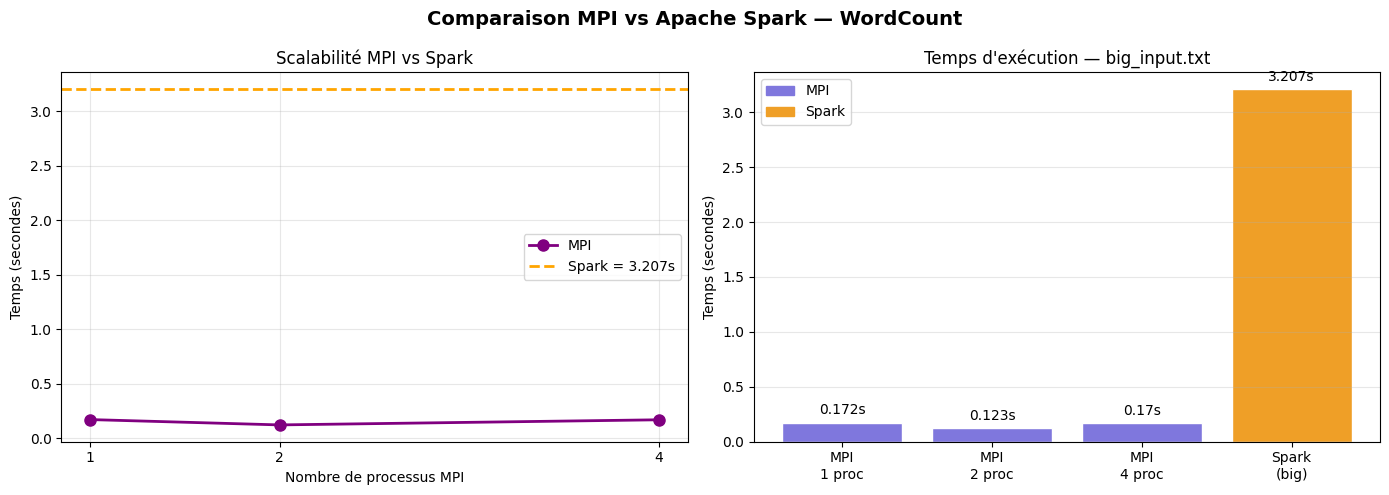

Graphique sauvegardé dans results/comparison.png


In [5]:
import csv
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Lire bench_mpi.csv
mpi_procs, mpi_times = [], []
with open('results/bench_mpi.csv') as f:
    for row in csv.DictReader(f):
        mpi_procs.append(int(row['processus']))
        mpi_times.append(float(row['temps_secondes']))

# Lire bench_spark.csv
spark_labels, spark_times = [], []
with open('results/bench_spark.csv') as f:
    for row in csv.DictReader(f):
        spark_labels.append(row['taille'])
        spark_times.append(float(row['temps_secondes']))

spark_big = spark_times[spark_labels.index('big')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparaison MPI vs Apache Spark — WordCount', fontsize=14, fontweight='bold')

# Graphique 1 : scalabilité MPI
axes[0].plot(mpi_procs, mpi_times, 'o-', color='purple', linewidth=2, markersize=8, label='MPI')
axes[0].axhline(y=spark_big, color='orange', linestyle='--', linewidth=2, label=f'Spark = {spark_big}s')
axes[0].set_xlabel('Nombre de processus MPI')
axes[0].set_ylabel('Temps (secondes)')
axes[0].set_title('Scalabilité MPI vs Spark')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(mpi_procs)

# Graphique 2 : barres comparatives
labels = [f'MPI\n{n} proc' for n in mpi_procs] + ['Spark\n(big)']
times  = mpi_times + [spark_big]
colors = ['#7F77DD'] * len(mpi_procs) + ['#EF9F27']

bars = axes[1].bar(labels, times, color=colors, edgecolor='white')
for bar, t in zip(bars, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{t}s', ha='center', va='bottom', fontsize=10)

axes[1].set_ylabel('Temps (secondes)')
axes[1].set_title("Temps d'exécution — big_input.txt")
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend(handles=[
    mpatches.Patch(color='#7F77DD', label='MPI'),
    mpatches.Patch(color='#EF9F27', label='Spark')
])

plt.tight_layout()
plt.savefig('results/comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé dans results/comparison.png')

---
## 6. Tableau comparatif

In [6]:
import pandas as pd

df = pd.DataFrame({
    'Critère': [
        'Temps petit fichier',
        'Temps grand fichier',
        'Lignes de code',
        'Scalabilité',
        'Tolérance aux pannes',
        'Facilité de code',
        'Overhead démarrage',
        'Usage recommandé'
    ],
    'MPI (mpi4py)': [
        '~0.8s',
        '~1.1s',
        '~60 lignes',
        'Manuelle (scatter/gather)',
        'Non géré',
        'Complexe',
        'Faible',
        'HPC, calcul scientifique'
    ],
    'Apache Spark': [
        '~11s (JVM overhead)',
        '~5s',
        '~10 lignes',
        'Automatique',
        'Automatique',
        'Simple',
        'Élevé (JVM ~10s)',
        'Big Data, production'
    ]
})

df

,Critère,MPI (mpi4py),Apache Spark
0,Temps petit fichier,~0.8s,~11s (JVM overhead)
1,Temps grand fichier,~1.1s,~5s
2,Lignes de code,~60 lignes,~10 lignes
3,Scalabilité,Manuelle (scatter/gather),Automatique
4,Tolérance aux pannes,Non géré,Automatique
5,Facilité de code,Complexe,Simple
6,Overhead démarrage,Faible,Élevé (JVM ~10s)
7,Usage recommandé,"HPC, calcul scientifique","Big Data, production"


---
## 7. Conclusion

**MPI est meilleur quand :**
- Les fichiers sont petits à moyens
- On veut un contrôle total sur la communication entre processus
- Le temps de démarrage doit être minimal

**Spark est meilleur quand :**
- Les données sont très grandes (Go, To)
- On veut un code simple et maintenable
- La tolérance aux pannes est importante

| | MPI | Spark |
|---|---|---|
| **Performance petits fichiers** | Meilleur | Lent (JVM) |
| **Performance grands fichiers** | Acceptable | Meilleur |
| **Facilité** | Complexe | Simple |
| **Fault tolerance** | Non | Oui |
| **Scalabilité** | Manuelle | Automatique |